In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

# Project paths
PROJECT_ROOT = Path("/DATA/home/jgarcia/SpectralSegmentation/C5-Project")
WEEK2_SRC = PROJECT_ROOT / "Week2" / "src"
if str(WEEK2_SRC) not in sys.path:
    sys.path.append(str(WEEK2_SRC))

from utils.kitti_dataset_motsio2 import KittiDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_val_dataset():
    return KittiDataset(
        str(PROJECT_ROOT / "Week2" / "data" / "KITTI-MOTS" / "training"),
        str(PROJECT_ROOT / "Week2" / "data" / "KITTI-MOTS" / "instances_txt"),
        str(PROJECT_ROOT / "Week2" / "src" / "utils" / "val.seqmap"),
        only_mask=False,
    )

def load_sam_models(
    base_checkpoint=PROJECT_ROOT / "Week2" / "src" /  "task_e" / "sam_vit_b_01ec64.pth",
    finetuned_checkpoint=PROJECT_ROOT / "Week2" / "src" /  "task_e" / "checkpoints" / "sam_task_e_best.pth",
    model_type="vit_b",
):
    pretrained = sam_model_registry[model_type](checkpoint=str(base_checkpoint)).to(DEVICE).eval()

    finetuned = sam_model_registry[model_type](checkpoint=str(base_checkpoint))
    state_dict = torch.load(finetuned_checkpoint, map_location=DEVICE)
    finetuned.load_state_dict(state_dict)
    finetuned = finetuned.to(DEVICE).eval()

    return pretrained, finetuned

def mask_to_box(mask: torch.Tensor):
    ys, xs = torch.where(mask > 0)
    if ys.numel() == 0 or xs.numel() == 0:
        return None
    return torch.tensor(
        [float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())],
        dtype=torch.float32,
    )

def prepare_image(image: torch.Tensor, model):
    resize_transform = ResizeLongestSide(model.image_encoder.img_size)
    image_np = (image.permute(1, 2, 0).cpu().numpy() * 255.0).astype(np.uint8)
    resized_image = resize_transform.apply_image(image_np)
    resized_size = resized_image.shape[:2]
    input_tensor = torch.as_tensor(resized_image, device=DEVICE).permute(2, 0, 1).contiguous()
    input_image = model.preprocess(input_tensor.unsqueeze(0))
    return input_image, image_np.shape[:2], resized_size, resize_transform

@torch.no_grad()
def predict_masks_from_gt_boxes(model, image: torch.Tensor, target: dict):
    gt_masks = target["masks"]
    gt_labels = target["labels"]
    input_image, original_size, resized_size, resize_transform = prepare_image(image.to(DEVICE), model)
    image_embeddings = model.image_encoder(input_image)

    pred_masks = []
    pred_scores = []
    boxes = []
    labels = []

    for mask, label in zip(gt_masks, gt_labels):
        box = mask_to_box(mask)
        if box is None:
            continue

        boxes.append(box.cpu())
        labels.append(int(label.item()))

        resized_box = resize_transform.apply_boxes_torch(box.unsqueeze(0), original_size).to(DEVICE)
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=None,
            boxes=resized_box,
            masks=None,
        )

        low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        upsampled_masks = model.postprocess_masks(
            low_res_masks,
            input_size=resized_size,
            original_size=original_size,
        )

        pred_masks.append((torch.sigmoid(upsampled_masks[:, 0]) > 0.5).cpu()[0])
        pred_scores.append(torch.sigmoid(iou_predictions[:, 0]).cpu()[0])

    if pred_masks:
        pred_masks = torch.stack(pred_masks)
        pred_scores = torch.stack(pred_scores)
    else:
        h, w = image.shape[1:]
        pred_masks = torch.zeros((0, h, w), dtype=torch.bool)
        pred_scores = torch.zeros((0,), dtype=torch.float32)

    return {
        "boxes": boxes,
        "labels": labels,
        "masks": pred_masks,
        "scores": pred_scores,
    }

def overlay_mask(ax, mask, color):
    h, w = mask.shape[-2:]
    overlay = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(overlay)

def draw_box(ax, box, color="lime", linewidth=2, label_text=None):
    x0, y0, x1, y1 = box
    rect = patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none",
    )
    ax.add_patch(rect)
    if label_text is not None:
        ax.text(
            x0, max(0, y0 - 5), label_text,
            color="white", fontsize=9,
            bbox=dict(facecolor="black", alpha=0.6, pad=2)
        )

def show_comparison(sample_idx=0):
    dataset = load_val_dataset()
    pretrained_model, finetuned_model = load_sam_models()

    image, target = dataset[sample_idx]
    image_np = image.permute(1, 2, 0).numpy()

    pred_pre = predict_masks_from_gt_boxes(pretrained_model, image, target)
    pred_ft = predict_masks_from_gt_boxes(finetuned_model, image, target)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    class_names = {1: "car", 2: "ped"}

    # Panel 1: image + GT boxes
    axes[0].imshow(image_np)
    axes[0].set_title("Val image + GT boxes")
    axes[0].axis("off")
    for box, label in zip(pred_pre["boxes"], pred_pre["labels"]):
        draw_box(axes[0], box.numpy(), color="lime", label_text=class_names.get(label, str(label)))

    # Panel 2: pretrained
    axes[1].imshow(image_np)
    axes[1].set_title("Pretrained SAM")
    axes[1].axis("off")
    for mask in pred_pre["masks"].numpy():
        overlay_mask(axes[1], mask, (1.0, 0.85, 0.0, 0.40))
    for box, score in zip(pred_pre["boxes"], pred_pre["scores"].numpy()):
        draw_box(axes[1], box.numpy(), color="cyan", label_text=f"{score:.3f}")

    # Panel 3: fine-tuned
    axes[2].imshow(image_np)
    axes[2].set_title("Fine-tuned SAM")
    axes[2].axis("off")
    for mask in pred_ft["masks"].numpy():
        overlay_mask(axes[2], mask, (0.10, 0.80, 0.30, 0.40))
    for box, score in zip(pred_ft["boxes"], pred_ft["scores"].numpy()):
        draw_box(axes[2], box.numpy(), color="cyan", label_text=f"{score:.3f}")

    plt.tight_layout()
    plt.show()

Loading seqmap...
Loading seqmap...


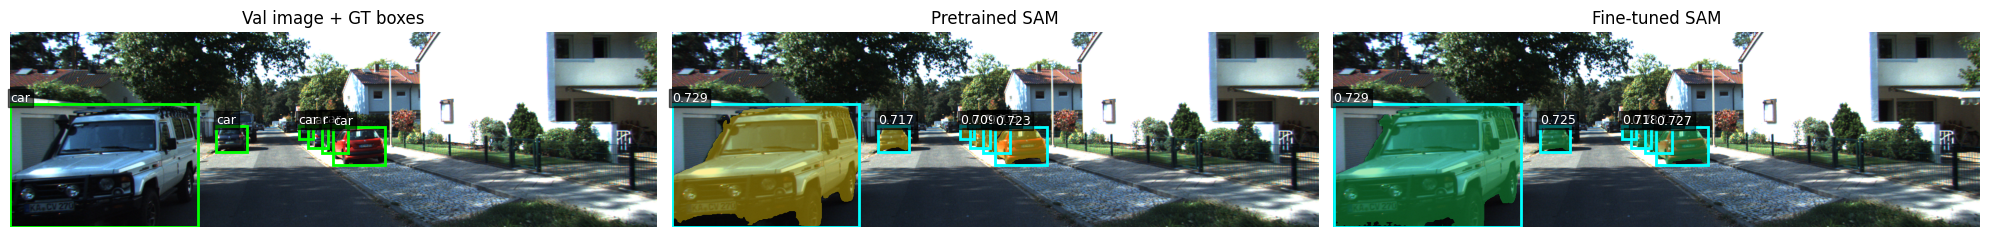

In [44]:
import random
random_idx = random.randint(0, len(load_val_dataset()) - 1)  # Get a random index from the validation set
show_comparison(sample_idx=random_idx)